# FirstAidQA — Data Ingestion, EDA, Cleaning & Splits


## 1. Install Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("Imports OK")

c:\Users\anany\Desktop\Northeastern\Year4\Spring2026\NLP\CS4120-First-Aid-Co-Pilot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2. Load Dataset

In [2]:
# FirstAidQA: primary training corpus 
raw1 = load_dataset("i-am-mushfiq/FirstAidQA")
df1 = raw1["train"].to_pandas()
df1["source"] = "FirstAidQA"
print(f"Dataset 1 (train corpus):   {len(df1):>6} rows")


Dataset 1 (train corpus):     5550 rows


In [3]:
# Sanity check on dataset shape and first rows
print(f"Shape: {df1.shape}")
df1.head(3)

Shape: (5550, 3)


,question,answer,source
0,When should you move an injured person at an a...,You should only move an injured person if ther...,FirstAidQA
1,What precautions should you take when moving a...,When moving a casualty with a potential spinal...,FirstAidQA
2,How should you move an unconscious casualty aw...,If you're alone and need to move an unconsciou...,FirstAidQA


## 3. Exploratory Data Analysis

In [4]:
# EDA: column names, data types, null counts, total rows
print("Columns:", df1.columns.tolist())
print("Dtypes:\n", df1.dtypes)
print("\nNull counts:\n", df1.isnull().sum())
print("\nTotal rows:", len(df1))

Columns: ['question', 'answer', 'source']
Dtypes:
 question    str
answer      str
source      str
dtype: object

Null counts:
 question    0
answer      0
source      0
dtype: int64

Total rows: 5550


In [5]:
# Character & word length distributions
df1["q_char_len"] = df1["question"].str.len()
df1["a_char_len"] = df1["answer"].str.len()
df1["q_word_len"] = df1["question"].str.split().str.len()
df1["a_word_len"] = df1["answer"].str.split().str.len()

print(df1[["q_char_len", "a_char_len", "q_word_len", "a_word_len"]].describe().round(1))

       q_char_len  a_char_len  q_word_len  a_word_len
count      5550.0      5550.0      5550.0      5550.0
mean         71.4       272.1        12.8        43.8
std          16.6        53.3         3.0         9.3
min          16.0        54.0         3.0         8.0
25%          60.0       236.0        11.0        37.0
50%          71.0       267.0        13.0        43.0
75%          82.0       305.0        15.0        49.0
max         155.0       760.0        25.0       138.0


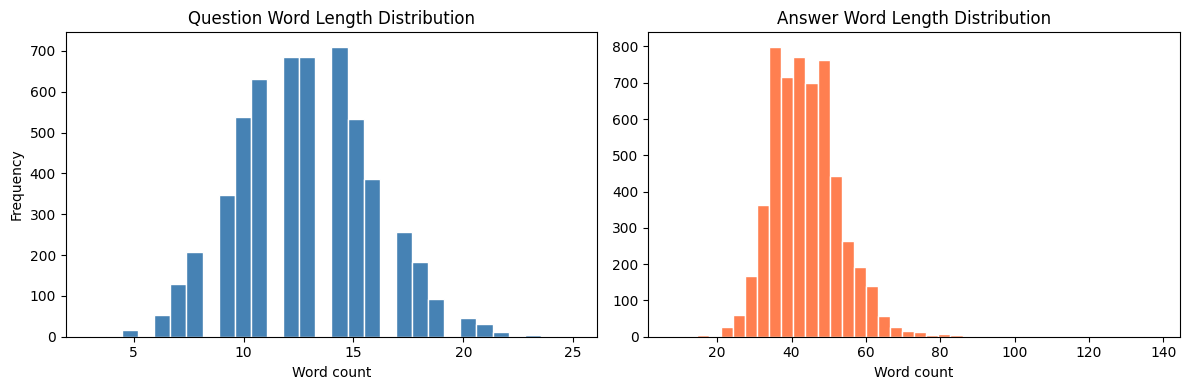

Saved length_distributions.png


In [6]:
# Plot length distributions 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df1["q_word_len"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Question Word Length Distribution")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Frequency")

axes[1].hist(df1["a_word_len"], bins=40, color="coral", edgecolor="white")
axes[1].set_title("Answer Word Length Distribution")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.savefig("length_distributions.png", dpi=150)
plt.show()
print("Saved length_distributions.png")

In [7]:
# Duplicate checks
exact_q_dups = df1["question"].duplicated().sum()
exact_a_dups = df1["answer"].duplicated().sum()
exact_pair_dups = df1.duplicated(subset=["question", "answer"]).sum()

print(f"Exact duplicate questions : {exact_q_dups}")
print(f"Exact duplicate answers   : {exact_a_dups}")
print(f"Exact duplicate QA pairs  : {exact_pair_dups}")

Exact duplicate questions : 60
Exact duplicate answers   : 41
Exact duplicate QA pairs  : 41


In [8]:
# Flag very short answers 
SHORT_ANSWER_THRESHOLD = 10  # words
short_answers = df1[df1["a_word_len"] < SHORT_ANSWER_THRESHOLD]
print(f"Answers under {SHORT_ANSWER_THRESHOLD} words: {len(short_answers)}")
short_answers[["question", "answer", "a_word_len"]].head(10)

Answers under 10 words: 1


,question,answer,a_word_len
904,What is the availability of antivenom for Funn...,An antivenom is available for Funnel-web spide...,8


## 4. Cleaning

In [9]:
df_clean = df1.copy()

# Strip leading/trailing whitespace 
df_clean["question"] = df_clean["question"].str.strip()
df_clean["answer"]   = df_clean["answer"].str.strip()

# Drop exact duplicate QA pairs
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["question", "answer"]).reset_index(drop=True)
print(f"Removed {before - len(df_clean)} exact duplicate rows. Remaining: {len(df_clean)}")

# Drop nulls 
df_clean = df_clean.dropna(subset=["question", "answer"]).reset_index(drop=True)
print(f"After null drop: {len(df_clean)} rows")

# Drop very short answers (< threshold)
df_clean = df_clean[df_clean["a_word_len"] >= SHORT_ANSWER_THRESHOLD].reset_index(drop=True)
print(f"After short-answer filter: {len(df_clean)} rows")

print("\nCleaning complete.")

Removed 41 exact duplicate rows. Remaining: 5509
After null drop: 5509 rows
After short-answer filter: 5508 rows

Cleaning complete.


In [10]:
# Normalized question column (for TF-IDF / retrieval)

def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["question_norm"] = df_clean["question"].apply(normalize_text)

df_clean[["question", "question_norm", "answer"]].head(3)

,question,question_norm,answer
0,When should you move an injured person at an a...,when should you move an injured person at an a...,You should only move an injured person if ther...
1,What precautions should you take when moving a...,what precautions should you take when moving a...,When moving a casualty with a potential spinal...
2,How should you move an unconscious casualty aw...,how should you move an unconscious casualty aw...,If you're alone and need to move an unconsciou...


## 5. Train / Dev / Test Split


In [11]:
# First split off test (10%)
df_traindev, df_test = train_test_split(df_clean, test_size=0.10, random_state=SEED)

# Then split train/dev from remaining 90% 
df_train, df_dev = train_test_split(df_traindev, test_size=0.111, random_state=SEED)

# Reset indices
df_train = df_train.reset_index(drop=True)
df_dev   = df_dev.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train : {len(df_train):>5} rows  ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"Dev   : {len(df_dev):>5} rows  ({len(df_dev)/len(df_clean)*100:.1f}%)")
print(f"Test  : {len(df_test):>5} rows  ({len(df_test)/len(df_clean)*100:.1f}%)")

Train :  4406 rows  (80.0%)
Dev   :   551 rows  (10.0%)
Test  :   551 rows  (10.0%)


## 6. Category Tagging

In [12]:
# Define keyword rules for IFRC high-risk categories
CATEGORY_KEYWORDS = {
    "choking":         ["chok", "airway obstruct", "heimlich", "back blow"],
    "cpr":             ["cpr", "cardiac arrest", "chest compression", "resuscitat", "aed", "defibrillator"],
    "severe_bleeding": ["bleed", "hemorrhag", "tourniquet", "wound", "pressure dressing"],
    "seizure":         ["seizure", "convuls", "epilep", "fit "],
    "stroke":          ["stroke", "face droop", "fast test", "brain attack"],
    "heart_attack":    ["heart attack", "myocardial", "chest pain", "cardiac"],
    "burns":           ["burn", "scald", "degree"],
    "fracture":        ["fracture", "broken bone", "splint", "bone"],
    "spinal_injury":   ["spinal", "spine", "neck injury", "vertebra"],
    "unconscious":     ["unconscious", "unresponsive", "recovery position", "not breathing"],
    "transportation":  ["human crutch", "drag", "move", "moving", "ambulance"],
    "allergies":       ["allerg", "epipen", "anaphyla", "reaction", "hive"],
}

def tag_category(text: str) -> str:
    """Return the first matching category, or 'other' if none match."""
    text_lower = text.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in text_lower for kw in keywords):
            return category
    return "other"

# Apply to the combined question + answer text for better recall
df_clean["category"] = (df_clean["question"] + " " + df_clean["answer"]).apply(tag_category)

print(df_clean["category"].value_counts())

category
other              1917
severe_bleeding     710
cpr                 599
transportation      453
fracture            402
choking             286
burns               271
stroke              177
unconscious         171
seizure             147
spinal_injury       140
allergies           130
heart_attack        105
Name: count, dtype: int64


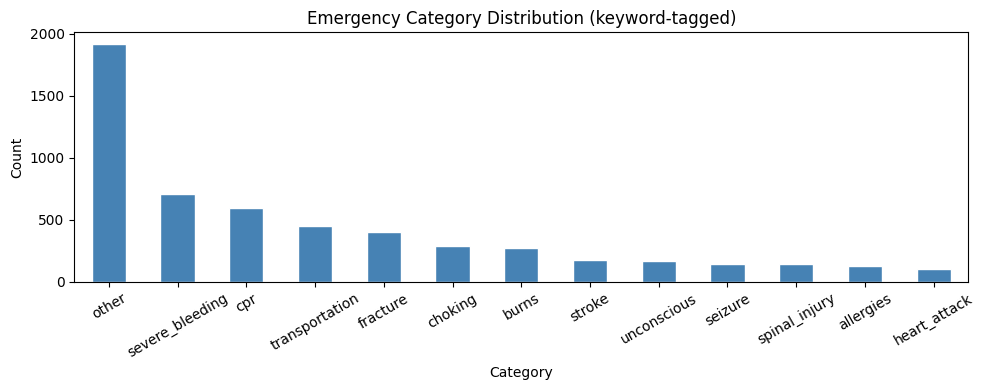

Saved category_distribution.png


In [13]:
# Visualize category distribution
cat_counts = df_clean["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
cat_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Emergency Category Distribution (keyword-tagged)")
ax.set_xlabel("Category")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=150)
plt.show()
print("Saved category_distribution.png")

## 7. Export

| File | Purpose |
|---|--- |
| `train.csv` | TF-IDF corpus + LM training |
| `dev.csv` | Retrieval tuning (choose k, n-gram) |
| `test.csv` | Held-out evaluation |
| `full_clean.csv` | Full cleaned dataset with category tags |


In [14]:
# Apply category tag to each split before exporting
df_train["category"] = (df_train["question"] + " " + df_train["answer"]).apply(tag_category)
df_dev["category"]   = (df_dev["question"]   + " " + df_dev["answer"]).apply(tag_category)
df_test["category"]  = (df_test["question"]  + " " + df_test["answer"]).apply(tag_category)

# Export
df_train.to_csv("train.csv",       index=False)
df_dev.to_csv("dev.csv",           index=False)
df_test.to_csv("test.csv",         index=False)
df_clean.to_csv("full_clean.csv",  index=False)

print("Exported:")
for fname, split in [("train.csv", df_train), ("dev.csv", df_dev), 
                     ("test.csv", df_test), ("full_clean.csv", df_clean)]:
        print(f"  {fname:<20s}  {len(split):>5} rows")

Exported:
  train.csv              4406 rows
  dev.csv                 551 rows
  test.csv                551 rows
  full_clean.csv         5508 rows
